Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d

plt.rcParams["figure.constrained_layout.use"] = True

Matplotlib is building the font cache; this may take a moment.


In [48]:
np.random.seed(123)

n_trials = 60
x = np.arange(0, n_trials)

mu_hr, sigma_hr = 75.0, 3.0
mu_bel, sigma_bel = 60.0, 5.0
alpha, beta = -10.0, 5.0
heart_rates = np.random.normal(mu_hr, sigma_hr, n_trials) + np.sin(x * .1)

f = interp1d(x, heart_rates, kind="cubic")
new_heart_rate = f(np.arange(0, n_trials-1, .001))

In [49]:
def weighted_bayesian_update(
    mu_0: float, mu_1: float, pi_0: float, pi_1: float, omega: float
):
    """Bayesian update for the mean and precision of a normal distribution."""
    pi = (1 - omega) * pi_0 + omega * pi_1
    mu = ((1 - omega) * mu_0 * pi_0 + omega * mu_1 * pi_1) / pi
    return mu, pi

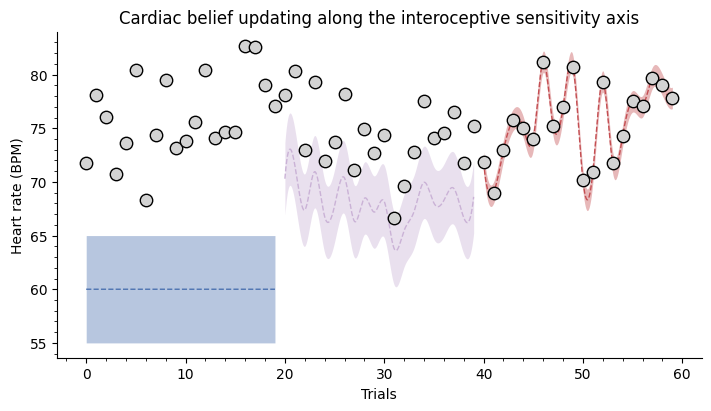

In [51]:
_, axs = plt.subplots(figsize=(7, 4))
axs.scatter(
    x,
    heart_rates,
    s=80,
    color="lightgrey",
    edgecolor="k",
    zorder=10
)

for start_idx, end_idx, omega, color in zip(range(0, 60, 20), range(20, 80, 20), [0.0, 0.05, 1.0], ["#4c72b0", "#cab2d6", "#c44e52"]):

    mu, pi = weighted_bayesian_update(mu_bel, heart_rates[start_idx:end_idx], 1/sigma_bel**2, 1.0, omega=omega)
    f = interp1d(x[start_idx:end_idx], mu, kind="cubic")
    new_mu = f(np.arange(start_idx, end_idx-1, .001))
    
    axs.fill_between(
        x=np.arange(start_idx, end_idx-1, .001),
        y1=new_mu - np.sqrt(1/pi),
        y2=new_mu + np.sqrt(1/pi),
        color=color,
        alpha=0.4,
        linewidth=0
    )
    
    axs.plot(
        np.arange(start_idx, end_idx-1, .001),
        new_mu,
        linestyle="--",
        linewidth=1,
        color=color,
    )

axs.set(title="Cardiac belief updating along the interoceptive sensitivity axis", ylabel="Heart rate (BPM)")
axs.minorticks_on()

axs.set(xlabel="Trials")

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_1_illustration.svg")